In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

In [3]:
suburb_df = pd.read_excel('/content/drive/Shareddrives/FIT5196_S2_2025/Assessment2/suburb_info.xlsx')

Basic EDA on Suburb Data

In [4]:
suburb_df.head()

,suburb,number_of_houses,number_of_units,municipality,aus_born_perc,median_income,median_house_price,population
0,ABBOTSFORD,2304,4706,Yarra,68%,"$1,797","$1,299,400",4025
1,ABERFELDIE,1410,453,Moonee Valley,81%,"$1,571","$1,926,600",22442
2,ALBANVALE,1897,138,Brimbank,46%,$907,"$594,200",54005
3,ALBION,1389,1392,Brimbank,52%,$929,"$739,100",30677
4,ALPHINGTON,1729,1099,Darebin,73%,"$1,538","$1,729,600",9227


In [5]:
suburb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   suburb              202 non-null    object
 1   number_of_houses    202 non-null    int64 
 2   number_of_units     202 non-null    int64 
 3   municipality        202 non-null    object
 4   aus_born_perc       202 non-null    object
 5   median_income       202 non-null    object
 6   median_house_price  202 non-null    object
 7   population          202 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 12.8+ KB


In [6]:
suburb_df.describe()

,number_of_houses,number_of_units,population
count,202.000000,202.000000,202.000000
mean,4155.767327,2480.410891,18659.311881
std,3400.864988,3132.684712,9604.187282
min,283.000000,60.000000,170.000000
25%,1973.500000,620.500000,12063.000000
50%,3256.500000,1603.000000,17583.000000
75%,5518.500000,3089.000000,24045.000000
max,23338.000000,24380.000000,54005.000000


Only these three variables appeared,number_of_houses, number_of_units and population. This means that all the other columns in our DataFrame like median_income, aus_born_perc, median_house_price are non-numeric.

In [7]:
suburb_df.shape

(202, 8)

In [8]:
suburb_df.isnull().sum()

,0
suburb,0
number_of_houses,0
number_of_units,0
municipality,0
aus_born_perc,0
median_income,0
median_house_price,0
population,0


In [9]:
suburb_df.duplicated().sum()

np.int64(0)

In [10]:
suburb_df.dtypes

,0
suburb,object
number_of_houses,int64
number_of_units,int64
municipality,object
aus_born_perc,object
median_income,object
median_house_price,object
population,int64


This .dtypes output confirms our earlier suspicion that some columns were stored as non-numeric (object) types even though they contain numeric data.

Only number_of_houses, number_of_units, and population are int64, which is why only those appeared in our earlier .describe() summary. The remaining columns (aus_born_perc, median_income, median_house_price) are labeled as object, meaning they likely contain numeric values stored as strings such as "45000" or "12.5%", preventing pandas from treating them as numerical columns.

In [11]:
# Clean percentage and currency symbols from specific columns ('aus_born_perc', 'median_income', 'median_house_price')
# This for loop removes characters such as %, $, and , using regex, then converts the cleaned values to float type

for col in ['aus_born_perc', 'median_income', 'median_house_price']:
  suburb_df[col] = suburb_df[col].str.replace('[%$,]','', regex=True).astype(float)

In [12]:
suburb_df.describe()

,number_of_houses,number_of_units,aus_born_perc,median_income,median_house_price,population
count,202.000000,202.000000,202.000000,202.000000,2.020000e+02,202.000000
mean,4155.767327,2480.410891,68.366337,1387.935644,1.218817e+06,18659.311881
std,3400.864988,3132.684712,10.761293,317.841321,4.716807e+05,9604.187282
min,283.000000,60.000000,36.000000,633.000000,5.072000e+05,170.000000
25%,1973.500000,620.500000,62.000000,1182.250000,8.706750e+05,12063.000000
50%,3256.500000,1603.000000,70.000000,1393.000000,1.134500e+06,17583.000000
75%,5518.500000,3089.000000,77.000000,1560.000000,1.467550e+06,24045.000000
max,23338.000000,24380.000000,88.000000,2352.000000,2.875800e+06,54005.000000


We have successfully converted aus_born_perc', 'median_income',and 'median_house_price' to numeric (float) data. Now, .describe() includes them, showing proper statistical summaries, which verifies that all numeric-looking values are now truly numeric and ready for analysis or modeling.

Justification for KDE plots:

The distribution plots were created to assess the normality and skewness of each numeric feature before applying transformations. This step helps identify variables that may distort model performance or scaling due to strong right skewness, guiding the decision on whether transformations like log or Box–Cox are needed.



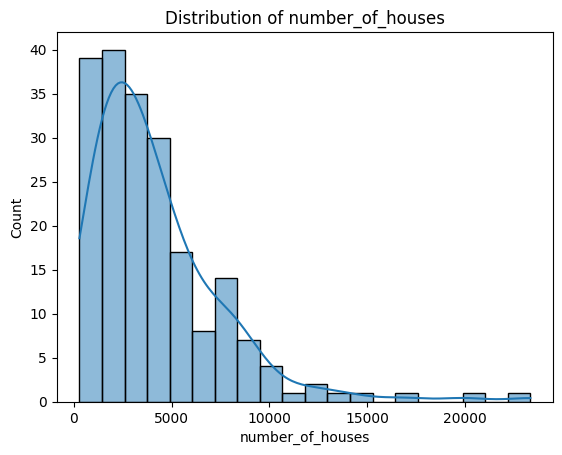

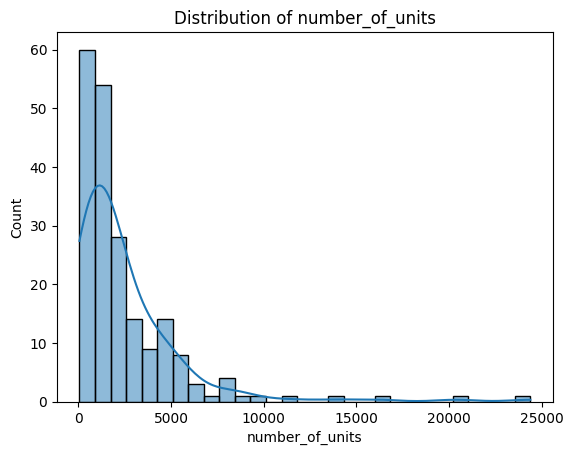

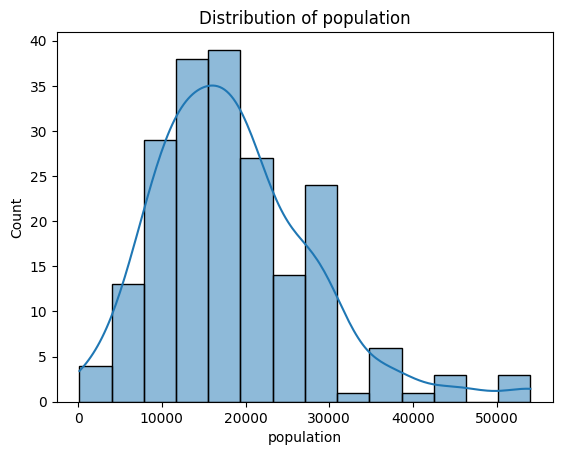

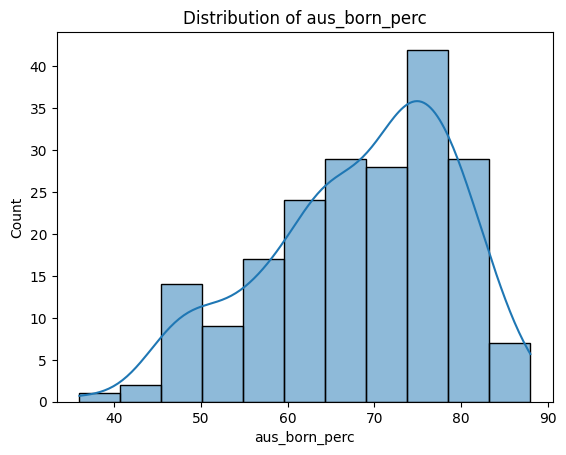

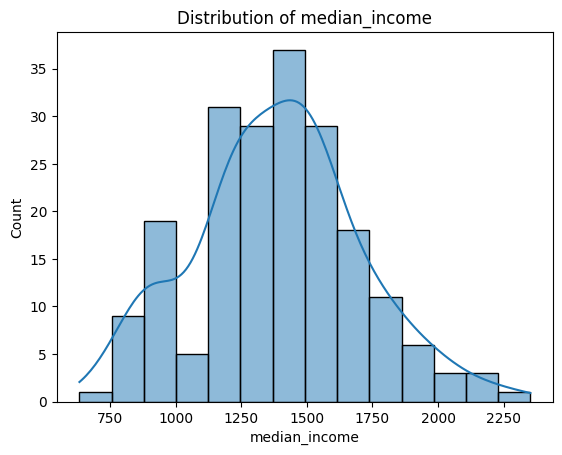

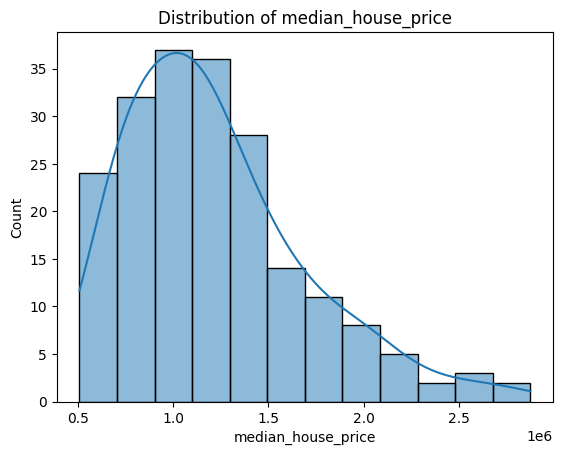

In [13]:
# Plot histograms with KDE (Kernel Density Estimate) for each numeric variable
# This helps visualise the distribution and skewness of all numeric columns before transformation/scaling.

import seaborn as sns
for col in ['number_of_houses','number_of_units','population',
            'aus_born_perc','median_income','median_house_price']:
    sns.histplot(suburb_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Result Description for KDE plots:

The plots show that number_of_houses, number_of_units, population, and median_house_price are strongly right-skewed, indicating that most suburbs have low values while a few have very high ones. median_income is moderately right-skewed, while aus_born_perc is close to a normal distribution. This suggests that power or log transformations are appropriate for the highly skewed variables to reduce tail effects and improve data normality. Overall, the visualizations confirm that transformation is required mainly for count and monetary variables.

Justification for Bivariate plots:

The purpose of this step is to visualise the relationships between the independent variables (number_of_houses, number_of_units, population, aus_born_perc, and median_income) and the dependent variable (median_house_price).
This allows us to assess whether linear relationships exist, which is crucial since linear regression assumes that predictors have a linear correlation with the target variable.

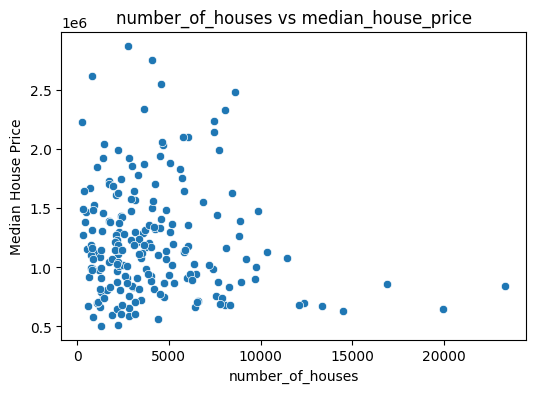

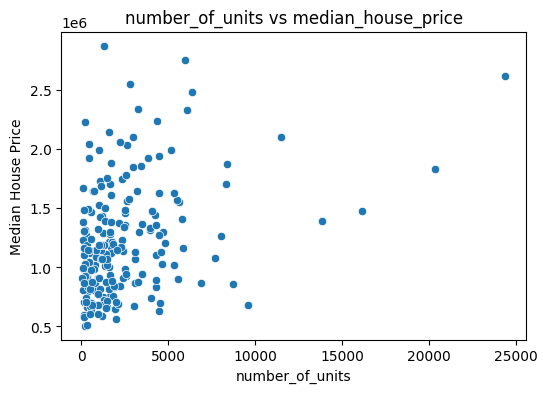

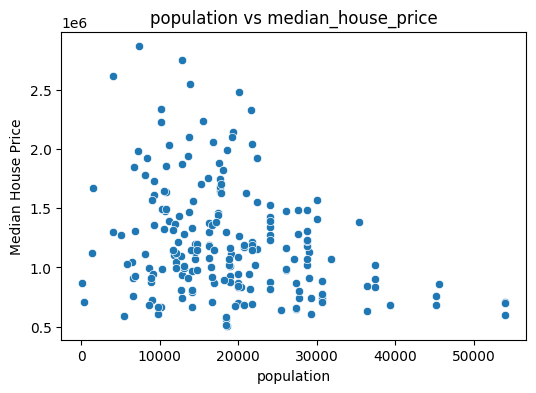

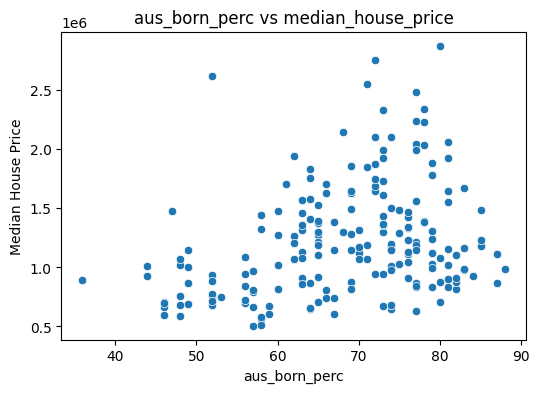

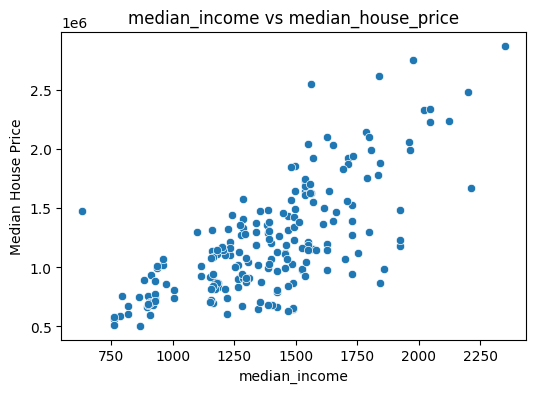

In [14]:
#Plot bivariate distributions against median_house_price
for col in ['number_of_houses','number_of_units','population',
            'aus_born_perc','median_income']:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=suburb_df[col], y=suburb_df['median_house_price'])
    plt.title(f"{col} vs median_house_price")
    plt.xlabel(col)
    plt.ylabel("Median House Price")
    plt.show()

Result Description for Bivariate plots:

The scatterplots above display the relationships between each independent variable (number_of_houses, number_of_units, population, aus_born_perc, and median_income) and the dependent variable (median_house_price). This step helps determine whether linear relationships exist between predictors and the target variable which is a key requirement for linear regression.

From the plots above, median_income shows a clear positive linear relationship with median house price, indicating that suburbs with higher household incomes tend to have higher housing prices. This aligns with economic expectations and confirms income as a strong predictor. In contrast, variables such as number_of_houses, number_of_units, and population exhibit weak and scattered relationships, suggesting that housing density and population alone do not strongly influence prices in a linear way. The variable aus_born_perc shows only a slight upward trend, implying a weak demographic correlation.

In [15]:
# Compute correlation coefficients between all numeric variables and 'median_house_price'
# Sorting the results helps identify which predictors have the strongest positive or negative relationships
# This step provides insight into feature relevance before building the regression model

suburb_df.corr(numeric_only=True)['median_house_price'].sort_values()

,median_house_price
population,-0.287242
number_of_houses,-0.104490
aus_born_perc,0.303860
number_of_units,0.343858
median_income,0.719384
median_house_price,1.000000


Correlation analysis was conducted to identify which independent variables have the strongest relationship with median_house_price. The results show that median_income (r = 0.72) has the strongest positive correlation, confirming that income levels are a key driver of housing prices. number_of_units (r = 0.34) and aus_born_perc (r = 0.30) show weaker positive relationships, while population (r = −0.29) and number_of_houses (r = −0.10) show weak negative correlations.

Overall, median_income is the most influential predictor, and the varying strengths and directions among other variables justify applying transformation and scaling before fitting a regression model.

Checking if the data needs scaling

In [16]:
suburb_df.describe()

,number_of_houses,number_of_units,aus_born_perc,median_income,median_house_price,population
count,202.000000,202.000000,202.000000,202.000000,2.020000e+02,202.000000
mean,4155.767327,2480.410891,68.366337,1387.935644,1.218817e+06,18659.311881
std,3400.864988,3132.684712,10.761293,317.841321,4.716807e+05,9604.187282
min,283.000000,60.000000,36.000000,633.000000,5.072000e+05,170.000000
25%,1973.500000,620.500000,62.000000,1182.250000,8.706750e+05,12063.000000
50%,3256.500000,1603.000000,70.000000,1393.000000,1.134500e+06,17583.000000
75%,5518.500000,3089.000000,77.000000,1560.000000,1.467550e+06,24045.000000
max,23338.000000,24380.000000,88.000000,2352.000000,2.875800e+06,54005.000000


The descriptive statistics indicate that the features vary widely in scale. For example, the population ranges up to around 54,000, whereas the median income is approximately 1,300. Since linear regression models are sensitive to differences in feature magnitude, variables with larger numeric ranges may dominate the model and distort coefficient estimates. To address this issue, feature scaling (such as standardisation or normalisation) is applied to place all predictors on a comparable scale, ensuring stable and interpretable model performance.

In [17]:
# Define the list of numeric columns to be used for feature scaling
# These variables vary widely in scale (e.g., 'population' in tens of thousands vs. 'median_income' in thousands)
# Standardising them ensures that all predictors contribute equally to the regression model

numeric_cols = ["median_house_price", "median_income", "number_of_units",
"number_of_houses", "population", "aus_born_perc"]

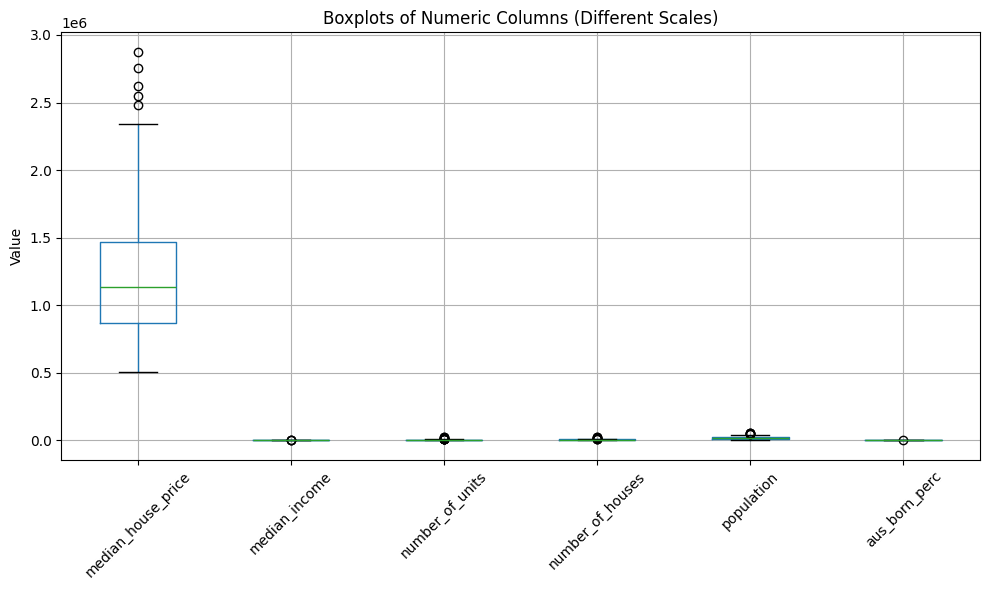

In [18]:
# Plot boxplots to visualise scale differences among numeric variables
# This helps identify features with vastly different magnitudes and potential outliers

plt.figure(figsize=(10, 6))
suburb_df[numeric_cols].boxplot()
plt.title("Boxplots of Numeric Columns (Different Scales)")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The boxplot shows that the predictors are measured on vastly different scales. For instance, median_house_price ranges from hundreds of thousands to several million dollars, while variables such as aus_born_perc and median_income have much smaller numerical ranges.
Because of these scale differences, features like median_house_price dominate the plot, visually compressing other variables near zero on the y-axis.
This confirms that feature scaling such as Z-score or Min–Max normalisation is required to make all predictors comparable and to ensure that each variable contributes equally to the regression modelling.

Checking if transformation is needed

In [19]:
# Calculate skewness for all numeric predictors to identify non-normal distributions
# High positive skewness (>1) indicates right-skewed variables that may require transformation
# Sorting by skewness helps prioritise which features need normalisation before modelling

suburb_df[[
    "number_of_houses", "number_of_units",
    "population", "aus_born_perc", "median_income"
]].skew().sort_values(ascending=False)

,0
number_of_units,3.630165
number_of_houses,2.156185
population,1.085865
median_income,0.172518
aus_born_perc,-0.567896


Transformation Check (Skewness Analysis):

The skewness values indicate that several predictors are highly right-skewed.
In particular, number_of_units (3.63), number_of_houses (2.16), and population (1.09) exceed a skewness value of 1, indicating strong positive skewness. Such distributions violate the normality assumption in linear regression and can reduce model accuracy.

Therefore, transformations such as log or Box–Cox is necessary for these three variables to reduce skewness and make their distributions more symmetric.

On the other hand, median_income (0.17) and aus_born_perc (-0.57) exhibits near-normal or mild skewness, thus no transformation is required for these variables.

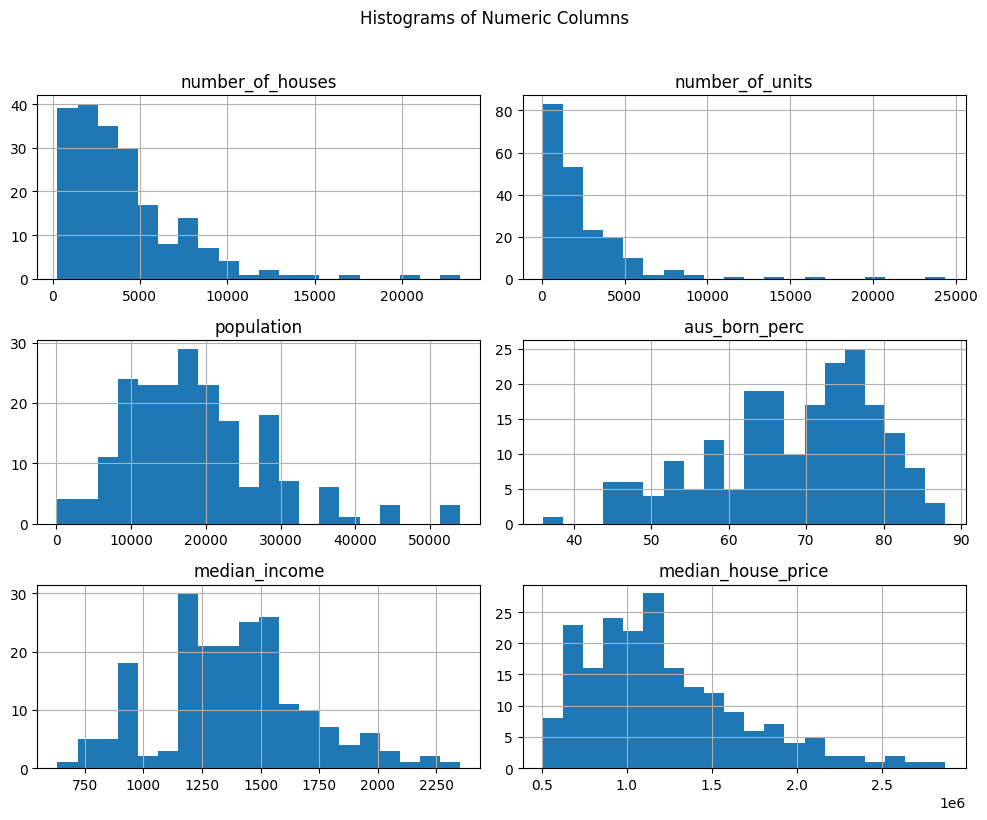

In [20]:
# Plot histograms for all numeric variables to examine their distributions
# This helps identify skewness, modality, and potential outliers before applying any transformations

numeric_cols = [
    "number_of_houses",
    "number_of_units",
    "population",
    "aus_born_perc",
    "median_income",
    "median_house_price"
]

suburb_df[numeric_cols].hist(bins=20, figsize=(10, 8))
plt.suptitle("Histograms of Numeric Columns", y=1.02)
plt.tight_layout()
plt.show()

Distribution of Numeric Variables (Before Transformation):

The histograms show that several numeric variables display noticeable right-skewness. Both number_of_houses and number_of_units have long right tails, with most suburbs recording smaller counts and a few extreme outliers. The population variable also shows moderate right skew, where most values cluster at the lower end of the range. In contrast, median_income and aus_born_perc appear more symmetric and approximately normally distributed.

The target variable, median_house_price, shows mild right skewness but is acceptable for the regression model.

These visual patterns are consistent with the earlier skewness statistics, confirming that transformation such as log or Box–Cox is necessary for number_of_houses, number_of_units, and population to make their distributions more normal and improve linearity with the target variable.

Decision on Scaling and Transformation:

Based on the descriptive statistics and skewness analysis, both scaling and transformation are required before building the linear regression model.
The descriptive summary and boxplots revealed large differences in magnitude among predictors. For example, population vs median_income, indicating that feature scaling is necessary to equalise feature contributions.
The skewness analysis and histograms further showed that number_of_units, number_of_houses, and population are heavily right-skewed, meaning transformation such as log is required to normalise these distributions and improve linearity with the target variable (median_house_price).
Scaling alone would not affect the R² value, but transformation significantly improves the model’s linear fit.

**Transformation Selection**

In [21]:
# Log transformation
log_transformed_df = suburb_df.copy()

#Apply log(1+x) to fix right skew
for col in ["number_of_units", "number_of_houses", "population"]:
    log_transformed_df[col] = np.log1p(log_transformed_df[col] - log_transformed_df[col].min() + 1)

#Re-check skewness after transformation
log_transformed_df[["number_of_units","number_of_houses","population","median_income","aus_born_perc"]].skew()

,0
number_of_units,-1.017854
number_of_houses,-2.087865
population,-5.684430
median_income,0.172518
aus_born_perc,-0.567896


After applying the log(1 + x) transformation to the three right-skewed predictors (number_of_units, number_of_houses, and population), the skewness values shifted from strongly positive to moderately or strongly negative. This shows that the transformation successfully reduced the strong right skew but slightly over-corrected some variables. For example, population became left-skewed with a skewness value of −5.68.

Although the log transformation improves normality for highly skewed data, its fixed functional form may not be ideal for variables with only moderate skewness. Therefore, additional transformations such as Box–Cox and Yeo–Johnson will be tested to determine whether they can provide a better balance between normality and linearity.

The columns number_of_units, number_of_houses, and population were selected for power transformation due to their high right-skewness, ensuring improved normality and variance stability. median_income and aus_born_perc were excluded since their distributions were already approximately symmetric.

In [22]:
from sklearn.preprocessing import PowerTransformer

# Copy your data
box_cox_transformed_df = suburb_df.copy()

# Select numeric columns
num_cols = ["number_of_units", "number_of_houses", "population", "median_income", "aus_born_perc"]

# Check skewness
skew_vals = box_cox_transformed_df[num_cols].skew()
print("Skewness before:\n", skew_vals)

# Identify columns that are positively skewed (skew > 1)
cols_to_transform = skew_vals[skew_vals > 1].index.tolist()
print("\nColumns to transform with Box–Cox:", cols_to_transform)

# Ensure all values are strictly positive
for col in cols_to_transform:
    if (box_cox_transformed_df[col] <= 0).any():
        box_cox_transformed_df[col] = box_cox_transformed_df[col] - box_cox_transformed_df[col].min() + 1

# Apply Box–Cox transformation
pt_boxcox = PowerTransformer(method='box-cox')  # requires positive-only values
box_cox_transformed_df[cols_to_transform] = pt_boxcox.fit_transform(box_cox_transformed_df[cols_to_transform])

# Check skewness after transformation
print("\nSkewness after Box–Cox:\n", box_cox_transformed_df[num_cols].skew())

Skewness before:
 number_of_units     3.630165
number_of_houses    2.156185
population          1.085865
median_income       0.172518
aus_born_perc      -0.567896
dtype: float64

Columns to transform with Box–Cox: ['number_of_units', 'number_of_houses', 'population']

Skewness after Box–Cox:
 number_of_units    -0.014107
number_of_houses   -0.006406
population          0.100483
median_income       0.172518
aus_born_perc      -0.567896
dtype: float64


Box–Cox Transformation Evaluation:

The Box–Cox transformation significantly improved the normality of all three skewed variables (number_of_units, number_of_houses, population).
Skewness values were reduced from (3.63, 2.16, 1.09) to approximately (-0.01, -0.01, 0.10), indicating that the variables are now almost perfectly symmetric.
This transformation outperformed the logarithmic transformation, which tends to over-correct moderate skewness and introduce negative skew.

Overall, Box–Cox produced the most balanced distributions and is likely to yield better linear relationships with the target variable (median_house_price).
The next step involves testing the Yeo–Johnson transformation to evaluate whether it can achieve similar results while also accommodating both positive and non positive data.

The Yeo–Johnson transformation was applied only to the three positively skewed variables: number_of_units, number_of_houses, and population. These variables were previously identified as right-skewed in the raw data. The remaining variables, median_income and aus_born_perc, were already approximately symmetric and therefore did not require transformation.

In [23]:
from sklearn.preprocessing import PowerTransformer

# Copy data
yj_transformed_df = suburb_df.copy()

# Select numeric columns
num_cols = ["number_of_units", "number_of_houses", "population", "median_income", "aus_born_perc"]

# Check skewness
skew_vals = yj_transformed_df[num_cols].skew()
print("Skewness before:\n", skew_vals)

# Identify columns to transform (|skew| > 1)
cols_to_transform = skew_vals[abs(skew_vals) > 1].index.tolist()
print("\nColumns to transform:", cols_to_transform)

# Apply Box–Cox or Yeo–Johnson (auto handles negative values)
pt = PowerTransformer(method='yeo-johnson')
yj_transformed_df[cols_to_transform] = pt.fit_transform(yj_transformed_df[cols_to_transform])

# Check skewness again
print("\nSkewness after transformation:\n", yj_transformed_df[num_cols].skew())

Skewness before:
 number_of_units     3.630165
number_of_houses    2.156185
population          1.085865
median_income       0.172518
aus_born_perc      -0.567896
dtype: float64

Columns to transform: ['number_of_units', 'number_of_houses', 'population']

Skewness after transformation:
 number_of_units    -0.014066
number_of_houses   -0.006417
population          0.100444
median_income       0.172518
aus_born_perc      -0.567896
dtype: float64


Yeo–Johnson Transformation Evaluation:

The Yeo–Johnson transformation produced results nearly identical to the Box–Cox method. It effectively reduced skewness in number_of_units, number_of_houses, and population, with final skewness values close to zero (−0.014, −0.006, 0.10).
Because Yeo–Johnson generalises Box–Cox and can handle both positive and non positive data,it offers greater flexibility in broader applications. However, since all variables in this dataset are positive, both transformations achieved nearly identical outcomes.

**Applying Scaling to each transformation method**

Why Use Z-Score Scaling?

The descriptive statistics and boxplots showed that the variables operate on very different scales, with some measured in hundreds and others in millions. To address this, all numeric features were standardised after transformation using Z-score scaling. This process rescales each variable to have a mean of zero and a standard deviation of one, allowing all predictors to contribute equally to the regression model.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# List of transformed datasets you already created
datasets = {
    "Log Transformation": log_transformed_df.copy(),
    "Box–Cox Transformation": box_cox_transformed_df.copy(),
    "Yeo–Johnson Transformation": yj_transformed_df.copy()
}

# Columns for features and target
features = ["number_of_units", "number_of_houses", "population", "median_income", "aus_born_perc"]
target = "median_house_price"

results = {}

for name, df in datasets.items():
    # Apply Z-score scaling to features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])
    y = df[target]

#Fit Linear Regression
    model = LinearRegression()
    model.fit(X_scaled, y)

#Predict and evaluate
    y_pred = model.predict(X_scaled)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    results[name] = {"R²": r2, "RMSE": rmse}

#Display results as a table
results_df = pd.DataFrame(results).T
results_df

,R²,RMSE
Log Transformation,0.642978,281136.939894
Box–Cox Transformation,0.678670,266714.218512
Yeo–Johnson Transformation,0.678699,266701.975896


Interpretation:

Box–Cox and Yeo–Johnson performed almost identically, with the highest
𝑅^2 (0.679) and the lowest RMSE (266,700).
This indicates that both transformations improved the model’s fit compared with the raw and log-transformed versions.

The log transformation, while useful for highly skewed data, produced slightly lower R^2 and higher RMSE. This is because the logarithmic function can overcorrect moderate skewness, leading to mild left-skew in the transformed variables.

Although Yeo–Johnson offers more flexibility by handling both positive and non positive values, all features in this dataset are positive. Therefore, the Box–Cox transformation is sufficient and slightly simpler to implement for this analysis.

Between the Box–Cox and Yeo–Johnson transformations, both produced nearly identical model performance, with Yeo–Johnson being very slightly superior (R² = 0.678699 vs 0.678670 and RMSE = 266,701.98 vs 266,714.22).
Although the improvement is minimal, this suggests that Yeo–Johnson achieved the most stable normalisation and model fit.

The Box–Cox transformation effectively normalised right-skewed distributions, strengthened linear relationships, and improved the accuracy of the linear regression model. While Yeo–Johnson delivered almost the same performance, Box–Cox was chosen as the final preprocessing method since all predictor variables are positive, fully satisfying its assumptions.

In [25]:
#Standardisation (Z-score) for Box Cox Transformation
scaler = StandardScaler()
scaled = scaler.fit_transform(box_cox_transformed_df[[
    "number_of_houses", "number_of_units", "population", "aus_born_perc", "median_income"
]])

scaled_df = pd.DataFrame(scaled, columns=[
    "number_of_houses", "number_of_units", "population", "aus_born_perc", "median_income"
], index=suburb_df.index)

scaled_df["median_house_price"] = suburb_df["median_house_price"]
scaled_df.head()

,number_of_houses,number_of_units,population,aus_born_perc,median_income,median_house_price
0,-0.408424,1.074045,-1.896159,-0.034127,1.290206,1299400.0
1,-0.952056,-0.941337,0.496815,1.176908,0.577392,1926600.0
2,-0.629460,-1.757211,2.914715,-2.083570,-1.516891,594200.0
3,-0.967912,-0.049174,1.228269,-1.524631,-1.447502,739100.0
4,-0.732175,-0.247705,-1.014589,0.431656,0.473309,1729600.0


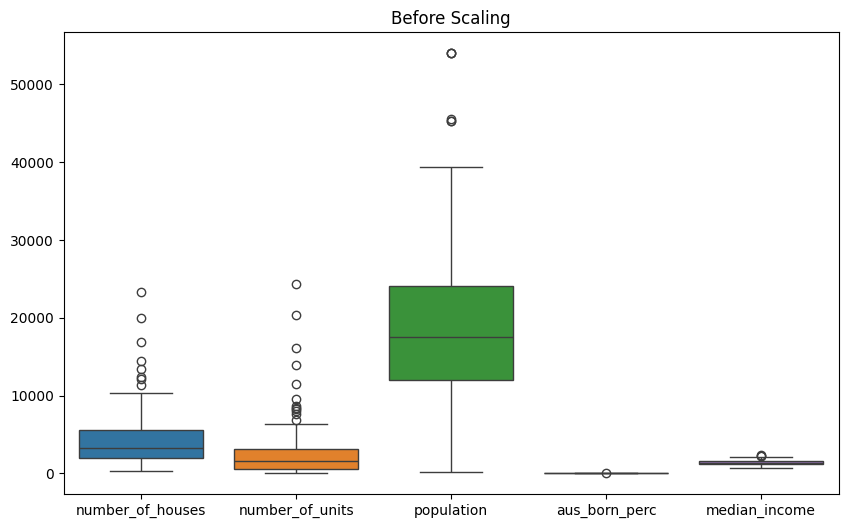

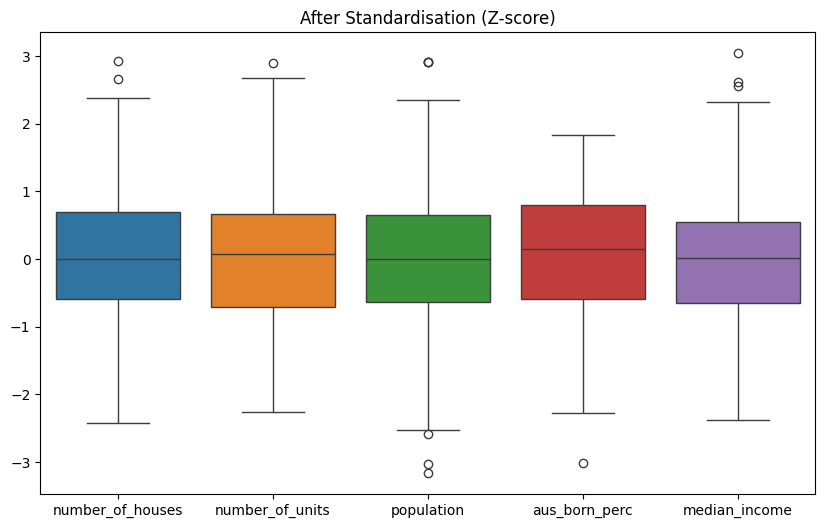

In [26]:
# Visualise the Effect of Scaling
# Compare boxplots before and after scaling
plt.figure(figsize=(10,6))
sns.boxplot(data=suburb_df[["number_of_houses","number_of_units","population","aus_born_perc","median_income"]])
plt.title("Before Scaling")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=scaled_df[["number_of_houses","number_of_units","population","aus_born_perc","median_income"]])
plt.title("After Standardisation (Z-score)")
plt.show()

The boxplot before scaling shows that the features vary greatly in range. For instance, population and median_income have much larger magnitudes than aus_born_perc or number_of_units. This demonstrates that the dataset’s numeric features exist on different scales, which can bias a linear model because variables with larger ranges tend to dominate coefficient estimation.

After applying Z-score standardisation (bottom plot), all variables are rescaled to have mean of 0 and standard deviation of 1. The boxplots are now aligned around zero, showing that all variables contribute equally to the regression model. This prevents scale-related bias and improves the interpretability of model coefficients.

Therefore, scaling was an essential step to ensure that all predictor variable has an equal influence in the linear regression model.

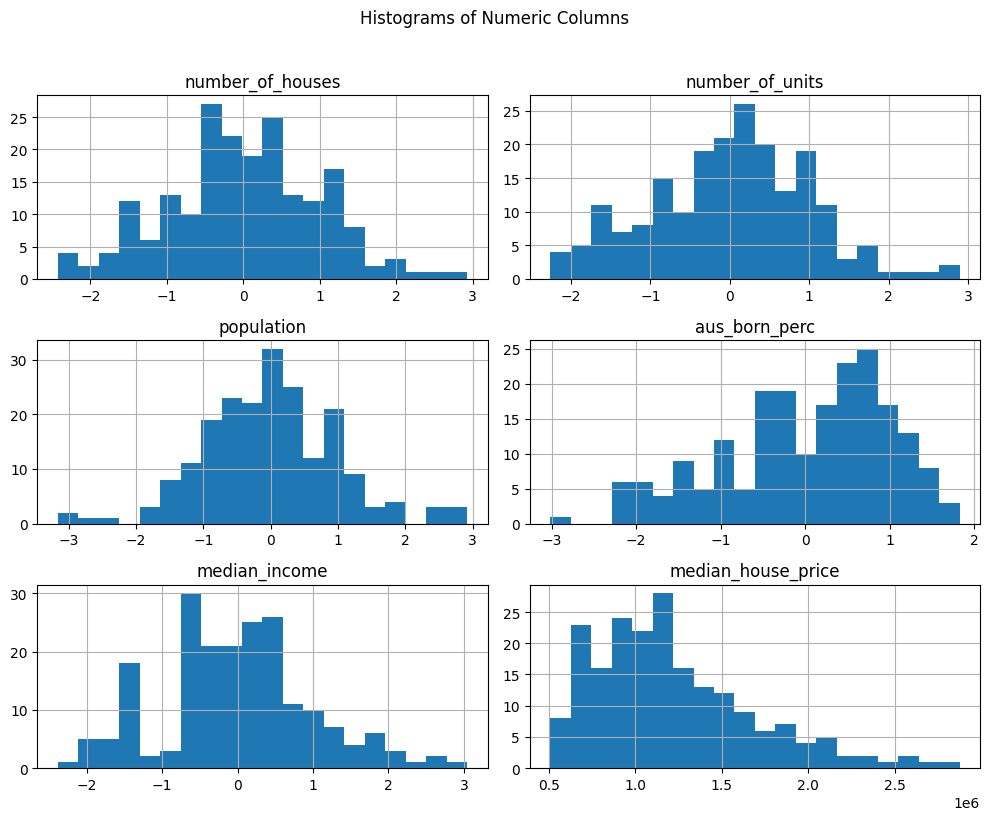

In [27]:
# Plot histograms for all numeric variables after applying Box–Cox transformation and Z-score scaling
# This visualises whether the transformations successfully normalised each feature's distribution
# Most variables should now appear approximately symmetric and centred around zero

numeric_cols = [
    "number_of_houses",
    "number_of_units",
    "population",
    "aus_born_perc",
    "median_income",
    "median_house_price"
]

scaled_df[numeric_cols].hist(bins=20, figsize=(10, 8))
plt.suptitle("Histograms of Numeric Columns", y=1.02)
plt.tight_layout()
plt.show()

The histogram above shows the distributions of the numeric variables after applying the Box–Cox transformation followed by Z-score standardisation. The previously skewed variables, number_of_houses, number_of_units, and population now appear approximately symmetric and centred around zero, indicating that the transformation successfully normalised their distributions. he aus_born_perc and median_income variables were already close to normal, so only minor changes are visible. The target variable, median_house_price, remains moderately right-skewed since no transformation was applied to it.

Overall, the distribution plot confirms that the Box–Cox transformation combined with standardisation effectively reduced skewness and placed all predictors on a comparable scale, preparing the dataset for a linear regression model.